✅ Step 0: 등급별 게임 수 (전체 모수: 9692개)
------------------------------------------------------------
performance_grade
high_high     898
high_mid      182
high_low      103
mid_high     2175
mid_mid       576
mid_low       465
low_high     3732
low_mid       615
low_low       946
Name: count, dtype: int64


C:\Users\asdxo\AppData\Local\Temp\ipykernel_12172\2143164209.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')


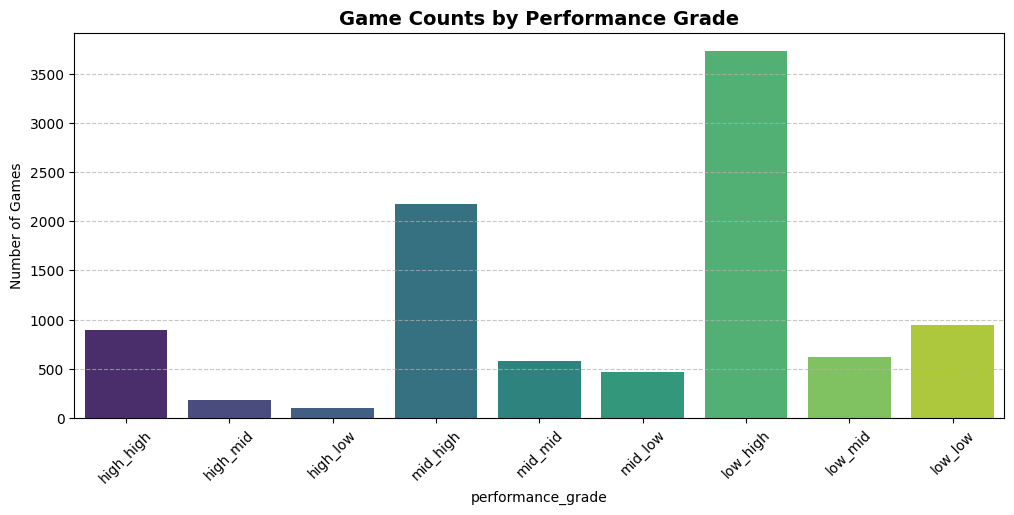

         Feature  Hedges' g
0      log_price     0.4995
1  positive_rate    -0.0296
2    value_score    -0.3008
------------------------------------------------------------
💡 가이드: 0.2(Small), 0.5(Medium), 0.8(Large)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier

# 1. 데이터 로드 및 전처리
# 파일명은 유저님의 환경에 맞게 수정하세요.
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 분석을 위한 추가 피처 생성
graded_df['log_price'] = np.log10(graded_df['price'] + 1) # 가격 왜곡 방지용 로그 변환
graded_df['value_score'] = graded_df['positive_rate'] / (graded_df['price'] + 1) # 가성비 지표
graded_df['success_target'] = (graded_df['performance_grade'] == 'high_high').astype(int) # HH 여부(타겟)

# ============================================================
# 📊 [Step 0] 등급별 게임 분포 확인
# ============================================================
grade_order = ['high_high', 'high_mid', 'high_low', 'mid_high', 'mid_mid', 'mid_low', 'low_high', 'low_mid', 'low_low']
grade_counts = graded_df['performance_grade'].value_counts().reindex(grade_order).fillna(0)

print("="*60)
print(f"✅ Step 0: 등급별 게임 수 (전체 모수: {len(graded_df)}개)")
print("-" * 60)
print(grade_counts)
print("="*60)

# 등급 분포 시각화
plt.figure(figsize=(12, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')
plt.title('Game Counts by Performance Grade', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Number of Games')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


def calculate_hedges_g(group1, group2, col):
    n1, n2 = len(group1), len(group2)
    v1, v2 = group1[col].var(), group2[col].var()
    m1, m2 = group1[col].mean(), group2[col].mean()
    
    # Pooled Standard Deviation
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    
    # Cohen's d 계산 후 Hedges' g 교정값 적용
    d = (m1 - m2) / pooled_std
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

hh = graded_df[graded_df['performance_grade'] == 'high_high']
mh = graded_df[graded_df['performance_grade'] == 'mid_high']

effect_results = []
# 가격은 로그 변환된 값(log_price)으로 보는 것이 통계적으로 더 정확합니다.
for f in ['log_price', 'positive_rate', 'value_score']:
    g = calculate_hedges_g(hh, mh, f)
    effect_results.append({'Feature': f, "Hedges' g": round(g, 4)})

print(pd.DataFrame(effect_results))
print("-" * 60)
print("💡 가이드: 0.2(Small), 0.5(Medium), 0.8(Large)")
print("="*60)

✅ [Step 0] 등급별 게임 분포 (전체 N = 9692)
----------------------------------------------------------------------
performance_grade
high_high     898
high_mid      182
high_low      103
mid_high     2175
mid_mid       576
mid_low       465
low_high     3732
low_mid       615
low_low       946
Name: count, dtype: int64


C:\Users\asdxo\AppData\Local\Temp\ipykernel_12172\3720506733.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='mako')


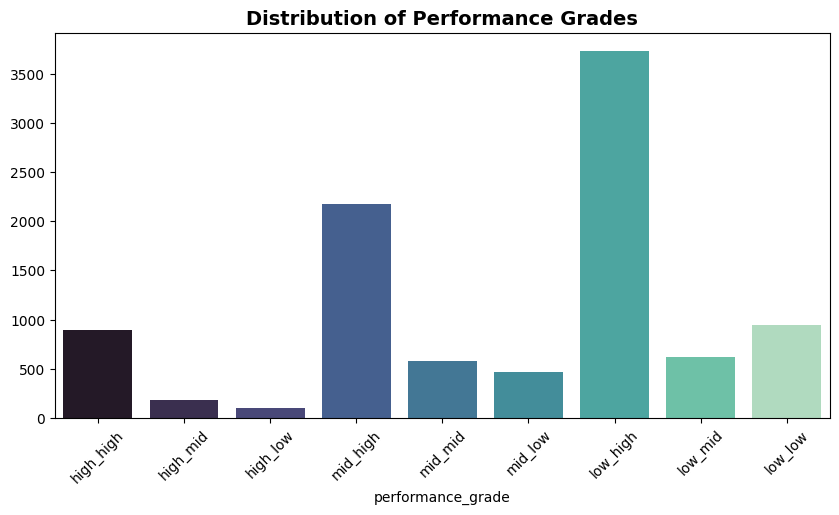


🔍 [Step 1] 5대 흥행 시그널 상관관계
               Signal  Correlation  p-value
0               price       0.1517      0.0
1       positive_rate       0.1380      0.0
2         value_score      -0.1114      0.0
3  achievements_total       0.2377      0.0
4       total_reviews       0.2424      0.0

🤖 [Step 2] 머신러닝 변수 중요도 (5대 시그널)
               Signal  Importance
4       total_reviews      0.7589
1       positive_rate      0.1756
0               price      0.0248
2         value_score      0.0237
3  achievements_total      0.0169

🧪 [Step 3] HH vs MH 실질 격차 분석 (Hedges' g)
               Signal  Hedges' g
0               price     0.5556
1       positive_rate    -0.0296
2         value_score    -0.3008
3  achievements_total     0.5464
4       total_reviews     0.5326


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier

# 1. 데이터 로드
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 5대 시그널 지수 생성 및 전처리
graded_df['value_score'] = graded_df['positive_rate'] / (graded_df['price'] + 1)
graded_df['log_price'] = np.log10(graded_df['price'] + 1)
graded_df['log_reviews'] = np.log10(graded_df['total_reviews'] + 1) # 규모 지수 로그화
graded_df['success_target'] = (graded_df['performance_grade'] == 'high_high').astype(int)

# 분석에 사용할 5개 핵심 지수 리스트
# [가격, 품질, 가성비, 업적, 규모]
features_5 = ['price', 'positive_rate', 'value_score', 'achievements_total', 'total_reviews']

# ============================================================
# 📊 [Step 0] 등급별 게임 수 확인 (가장 먼저 수행)
# ============================================================
grade_order = ['high_high', 'high_mid', 'high_low', 'mid_high', 'mid_mid', 'mid_low', 'low_high', 'low_mid', 'low_low']
grade_counts = graded_df['performance_grade'].value_counts().reindex(grade_order).fillna(0)

print("="*70)
print(f"✅ [Step 0] 등급별 게임 분포 (전체 N = {len(graded_df)})")
print("-" * 70)
print(grade_counts)
print("="*70)

# 시각화: 등급별 분포
plt.figure(figsize=(10, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='mako')
plt.title('Distribution of Performance Grades', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 🔍 [Step 1] 5개 시그널 상관관계 분석
# ============================================================
corr_results = []
for f in features_5:
    temp = graded_df[[f, 'success_target']].dropna()
    r, p = pearsonr(temp[f], temp['success_target'])
    corr_results.append({'Signal': f, 'Correlation': round(r, 4), 'p-value': round(p, 6)})

print("\n🔍 [Step 1] 5대 흥행 시그널 상관관계")
print(pd.DataFrame(corr_results))

# ============================================================
# 🤖 [Step 2] 5개 시그널 머신러닝 중요도
# ============================================================
X = graded_df[features_5].fillna(0)
y = graded_df['success_target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    'Signal': features_5,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🤖 [Step 2] 머신러닝 변수 중요도 (5대 시그널)")
print(importances.round(4))

# ============================================================
# 🧪 [Step 3] 5개 시그널 효과 크기 분석 (HH vs MH)
# ============================================================
def calculate_hedges_g(group1, group2, col):
    n1, n2 = len(group1), len(group2)
    v1, v2 = group1[col].var(), group2[col].var()
    m1, m2 = group1[col].mean(), group2[col].mean()
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    if pooled_std == 0: return 0
    d = (m1 - m2) / pooled_std
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

hh = graded_df[graded_df['performance_grade'] == 'high_high']
mh = graded_df[graded_df['performance_grade'] == 'mid_high']

effect_results = []
# 시각적 왜곡 방지를 위해 가격과 규모는 로그 변환값 사용을 권장하지만, 일단 5개 지수 원형 유지
for f in features_5:
    g = calculate_hedges_g(hh, mh, f)
    effect_results.append({'Signal': f, "Hedges' g": round(g, 4)})

print("\n🧪 [Step 3] HH vs MH 실질 격차 분석 (Hedges' g)")
print(pd.DataFrame(effect_results))
print("="*70)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier

# 1. 데이터 로드 및 174개 정예 표본 추출
games_df = pd.read_csv('steam_indie_games_graded.csv')
reviews_df = pd.read_csv('steam_indie_reviews.csv')
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
games_df['release_date'] = pd.to_datetime(games_df['release_date'])

# 시계열 병합 및 필터링
merged = pd.merge(reviews_df, games_df[['appid', 'release_date']], on='appid')
merged['days_diff'] = (merged['created_date'] - merged['release_date']).dt.days

# 지표 계산을 위한 그룹화
early_counts = merged[merged['days_diff'].between(0, 90)].groupby('appid').size()
long_counts = merged[merged['days_diff'].between(91, 365)].groupby('appid').size()
valid_ids = early_counts.index.intersection(long_counts.index)

# 분석용 데이터프레임(df_signal) 구축
df_signal = games_df[games_df['appid'].isin(valid_ids)].copy()

# [5대 시그널 정의]
# 1. Velocity (절대적 규모)
df_signal['Velocity'] = df_signal['total_reviews']

# 2. Loyalty (몰입 깊이/롱테일)
df_signal['Loyalty'] = df_signal['appid'].map(long_counts) / df_signal['appid'].map(early_counts)

# 3. Sentiment (만족도)
df_signal['Sentiment'] = df_signal['positive_rate']

# 4. Stability (안정성: 초기 90일 긍정률 변동성의 역수)
# 일자별 긍정률 계산 후 표준편차의 역수를 취함
def calc_stability(appid):
    daily = merged[(merged['appid'] == appid) & (merged['days_diff'].between(0, 90))]
    daily_rate = daily.groupby('days_diff')['voted_up'].mean()
    return 1 / (daily_rate.std() + 0.01) # 분모 0 방지

df_signal['Stability'] = df_signal['appid'].apply(calc_stability)

# 5. Value Score (가성비)
df_signal['Value_Score'] = df_signal['positive_rate'] / (df_signal['price'] + 1)

# 타겟 설정 (HH 여부)
df_signal['target'] = (df_signal['performance_grade'] == 'high_high').astype(int)
features = ['Velocity', 'Loyalty', 'Sentiment', 'Stability', 'Value_Score']

# ============================================================
# 📊 [Step 0] 등급별 게임 수 확인
# ============================================================
grade_counts = df_signal['performance_grade'].value_counts()
print("="*70)
print(f"✅ [Step 0] 분석 대상 게임 수 (시계열 확보 표본: {len(df_signal)}개)")
print("-" * 70)
print(grade_counts)
print("="*70)

# ============================================================
# 🔍 [Step 1] 5대 시그널 상관관계 분석
# ============================================================
corr_list = []
for f in features:
    r, p = pearsonr(df_signal[f], df_signal['target'])
    corr_list.append({'Signal': f, 'Correlation': round(r, 4), 'p-value': round(p, 6)})

# ============================================================
# 🤖 [Step 2] 머신러닝 변수 중요도
# ============================================================
X = df_signal[features].fillna(0)
y = df_signal['target']
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.DataFrame({'Signal': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

# ============================================================
# 🧪 [Step 3] Hedges' g 효과 크기 분석 (HH vs MH)
# ============================================================
def calculate_hedges_g(group1, group2, col):
    n1, n2 = len(group1), len(group2)
    v1, v2 = group1[col].var(), group2[col].var()
    m1, m2 = group1[col].mean(), group2[col].mean()
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return ((m1 - m2) / pooled_std) * (1 - (3 / (4 * (n1 + n2) - 9)))

hh = df_signal[df_signal['performance_grade'] == 'high_high']
mh = df_signal[df_signal['performance_grade'] == 'mid_high']

effect_res = []
for f in features:
    # Velocity는 로그 변환 후 비교 (Hedges' g의 정교함 유지)
    val_f = np.log10(df_signal[f] + 1) if f == 'Velocity' else df_signal[f]
    g = calculate_hedges_g(hh, mh, f)
    effect_res.append({'Signal': f, "Hedges' g": round(g, 4)})

# 결과 출력
print("\n🔍 [Step 1] 5대 시그널 상관관계")
print(pd.DataFrame(corr_list))
print("\n🤖 [Step 2] 머신러닝 변수 중요도")
print(importances.round(4))
print("\n🧪 [Step 3] HH vs MH 실질 격차 (Hedges' g)")
print(pd.DataFrame(effect_res))

FileNotFoundError: [Errno 2] No such file or directory: 'steam_indie_games_graded.csv'